# Predicting the Correct Bill from the CRM: a Telecom Provisioning Case Study

**Case Study I · Sprint 3 final notebook** · Moodle section 8608

A 4-Play subscription (internet, TV, mobile and fixed line) is set up in several systems. The
**CRM** records what the customer bought; the **billing system** charges for it. Human and
automatic errors make the two drift apart. This notebook does two things:

1. **Predicts the bill a customer should have** from their CRM configuration, so that mismatches
   can be caught.
2. **Detects suspected fraud**: customers whose CRM holds a product that is not billed.

| | |
|---|---|
| Input | 745 yes/no CRM product flags per customer |
| Output | 731 yes/no billing items per customer |
| Metric | Exact Match Ratio (EMR): a customer counts only if all 731 items are right |
| **Test EMR** | **97.51%** (95% CI 97.41–97.61), 94,681 of 97,100 customers exactly right |
| **Suspected fraud** | **16,237** training customers (8.7%) hold a CRM product that is not billed |

### Contents

1. [Setup](#setup)
2. [The data](#data)
3. [Validation strategy](#validation)
4. [Cleaning the training data](#audit)
5. [The model](#model)
6. [Business use: catching provisioning errors](#business)
7. [Explainability: what did the model learn?](#shap)
8. [Final training and submission](#submission)
9. [Test results](#test)
10. [Fraud detection: products added to the CRM without billing](#fraud)
11. [Conclusions](#conclusions)

**About this notebook.** It is self-contained and reads only the three files provided by the
professor (`train.csv`, `test.csv` and `solution.csv`). `solution.csv` is read only in Chapter 9,
after the model is frozen, and is never used to train or choose anything. It writes three files
to `data/derived/`: `submission.csv` (test predictions), `train_flags.csv` (training rows removed
from training or suspected of fraud) and `fraud_columns.csv` (CRM products ranked by suspected
fraud). A full run takes 35 to 65 minutes, depending on the machine.

<a id="setup"></a>
# 1. Setup

Libraries, the data folder, and one shared chart style.

In [1]:
import os
import re
import time
import warnings

os.environ.setdefault('OMP_NUM_THREADS', '6')
warnings.filterwarnings('ignore', message='X does not have valid feature names')

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from scipy.stats import spearmanr
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import GroupShuffleSplit, KFold

DATA = '../data'          # train.csv, test.csv, solution.csv (as provided by the professor)
OUT = f'{DATA}/derived'   # where the submission file is written
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.width', 160)

# Chart style: one light surface, recessive axes, blue / orange series.
SURFACE, INK, INK2, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
BLUE, LIGHT_BLUE, ORANGE = '#2a78d6', '#9ec5f4', '#eb6834'
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 9, 'figure.facecolor': SURFACE})


def style(ax, grid='x'):
    ax.set_facecolor(SURFACE)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=8)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)

<a id="data"></a>
# 2. The data

Every CRM and billing column is a 0/1 flag, so the files are read with a compact `uint8` type
instead of pandas' default `int64`, which would use eight times the memory.

In [2]:
t0 = time.time()
header = pd.read_csv(f'{DATA}/train.csv', nrows=0).columns.tolist()
crm_cols = [c for c in header if c.startswith('CRM')]
bil_cols = [c for c in header if c.startswith('BIL')]
dtypes = {c: 'uint8' for c in crm_cols + bil_cols} | {'MSISDN': str}

train = pd.read_csv(f'{DATA}/train.csv', dtype=dtypes)
test = pd.read_csv(f'{DATA}/test.csv', dtype={k: v for k, v in dtypes.items() if k in set(crm_cols) | {'MSISDN'}})
X = train[crm_cols].to_numpy(np.uint8)
Y_raw = train[bil_cols].to_numpy(np.uint8)
X_test = test[crm_cols].to_numpy(np.uint8)
msisdn_test = test['MSISDN'].to_numpy()
del train

print(f'train: {X.shape[0]:,} rows x {X.shape[1]} CRM + {Y_raw.shape[1]} BIL columns | '
      f'test: {X_test.shape[0]:,} rows | loaded in {time.time() - t0:.0f}s')
print(f'all values binary: {max(X.max(), Y_raw.max(), X_test.max()) <= 1}')

train: 187,442 rows x 745 CRM + 731 BIL columns | test: 97,100 rows | loaded in 25s
all values binary: True


### How sparse is the billing side?

In [3]:
pack_crm = np.array([c.endswith('_PACK') for c in crm_cols])
pack_bil = np.array([c.endswith('_PACK') for c in bil_cols])
print(f'CRM: {pack_crm.sum()} pack flags + {(~pack_crm).sum()} categorical one-hot columns')
print(f'BIL: {pack_bil.sum()} pack flags + {(~pack_bil).sum()} categorical one-hot columns')
print(f'active columns per customer: CRM {X.sum(1).mean():.1f}, BIL {Y_raw.sum(1).mean():.1f}')

prev = Y_raw.mean(0)
tiers = pd.cut(prev, [-1e-9, 0.001, 0.01, 0.1, 0.5, 1.0],
               labels=['< 0.1%', '0.1–1%', '1–10%', '10–50%', '≥ 50%'])
print('\nBIL columns by prevalence (share of customers who have the item):')
display(pd.Series(tiers).value_counts().sort_index().rename('BIL columns').to_frame().T)

CRM: 730 pack flags + 15 categorical one-hot columns
BIL: 717 pack flags + 14 categorical one-hot columns


active columns per customer: CRM 15.3, BIL 14.7

BIL columns by prevalence (share of customers who have the item):


,< 0.1%,0.1–1%,1–10%,10–50%,≥ 50%
BIL columns,10,607,82,23,9


A typical customer has about 15 of the 731 billing items, and more than 600 billing items
appear in fewer than 1% of customers. Getting *every* item right is hard, because most items
are rare.

### Duplicates, noise, and how new the test customers are

In [4]:
def row_keys(A):
    # Exact identity of each 0/1 row as bytes (np.packbits): no hashing, no collisions.
    return [r.tobytes() for r in np.packbits(np.asarray(A, dtype=np.uint8), axis=1)]


def factorize_rows(A):
    codes, uniq = pd.factorize(pd.Series(row_keys(A)), sort=False)
    return codes.astype(np.int64), len(uniq)


groups, n_crm_cfg = factorize_rows(X)
bil_codes, n_bil_cfg = factorize_rows(Y_raw)
pairs = pd.DataFrame({'crm': groups, 'bil': bil_codes})
n_bil_per_crm = pairs.groupby('crm')['bil'].nunique()
train_keys = set(row_keys(X))
seen = sum(k in train_keys for k in row_keys(X_test))

print(f'distinct CRM configurations: {n_crm_cfg:,} | distinct BIL configurations: {n_bil_cfg:,}')
print(f'CRM configurations with more than one BIL configuration (provisioning errors): '
      f'{(n_bil_per_crm > 1).sum():,} ({(n_bil_per_crm > 1).mean():.2%})')
print(f'test rows whose CRM configuration appears in train: {seen} of {len(X_test):,} ({seen / len(X_test):.4%})')

distinct CRM configurations: 67,434 | distinct BIL configurations: 67,201
CRM configurations with more than one BIL configuration (provisioning errors): 617 (0.91%)
test rows whose CRM configuration appears in train: 6 of 97,100 (0.0062%)


Three facts from this cell shaped the whole project:
- **The training labels contain noise.** In about 1% of CRM configurations, customers with
  identical CRM records have different bills. These are the provisioning errors the brief
  warns about.
- **Test customers are new.** Only 6 of 97,100 test customers have a CRM configuration that
  appears in training. A lookup table cannot work: the model has to generalise.
- **The mapping is many-to-one.** Different CRM configurations can lead to the same bill.

<a id="validation"></a>
# 3. Validation strategy

Because the test customers are new, validation must also use customers the model has never
seen.
- **Grouped split.** Customers with an identical CRM configuration always stay on the same side
  of the split (20% validation). The split uses seed 42.
- **Consensus targets.** When a CRM configuration appears several times, validation scores
  against its most frequent bill. This way the model is not rewarded for copying provisioning
  errors.

In [5]:
def consensus_targets(crm_codes, Y):
    # Modal full BIL configuration per CRM configuration (ties: first seen).
    codes, _ = factorize_rows(Y)
    p = pd.DataFrame({'crm': crm_codes, 'bil': codes, 'pos': np.arange(len(Y))})
    cnt = p.groupby(['crm', 'bil'], sort=False).agg(n=('pos', 'size'), first=('pos', 'min')).reset_index()
    modal = cnt.sort_values(['crm', 'n', 'first'], ascending=[True, False, True]).drop_duplicates('crm')
    src = modal.set_index('crm')['first'].reindex(crm_codes).to_numpy()
    return Y[src], codes != codes[src]


def grouped_holdout(groups, seed=42):
    return next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                .split(np.zeros(len(groups)), groups=groups))


Y, noisy = consensus_targets(groups, Y_raw)
tr, va = grouped_holdout(groups)
print(f'training rows that differ from their configuration consensus: {noisy.sum():,} ({noisy.mean():.2%})')
print(f'train fold {len(tr):,} rows | validation fold {len(va):,} rows | configurations on both sides: '
      f'{len(set(groups[tr]) & set(groups[va]))}')

training rows that differ from their configuration consensus: 1,315 (0.70%)
train fold 151,057 rows | validation fold 36,385 rows | configurations on both sides: 0


About 0.7% of training rows differ from their configuration's consensus bill, and no
configuration appears on both sides of the split.

<a id="audit"></a>
# 4. Cleaning the training data

An audit of every family of columns found two problems that exist only in the training data.

### Finding 1: impossible categories exist only in training

Business line, subscriber type and subscriber status are one-hot blocks, so each customer
should have exactly one value in each. We call a row **test-like** when every block has exactly
one value and never the placeholder value `0`.

In [6]:
def test_like_mask(A):
    blocks = {}
    for i, c in enumerate(crm_cols):
        m = re.match(r'^CRM_(.+?)_ORIG_(.+)$', c)
        if m:
            blocks.setdefault(m.group(1), []).append((i, m.group(2)))
    ok = np.ones(len(A), bool)
    for items in blocks.values():
        ok &= A[:, [i for i, _ in items]].sum(1) == 1
        zero = [i for i, v in items if v == '0']
        if zero:
            ok &= A[:, zero].sum(1) == 0
    return ok


test_like = test_like_mask(X)
print(f'test-like rows: train {test_like.mean():.2%} | test {test_like_mask(X_test).mean():.4%}')

status = np.array([c.startswith('CRM_SUBSCRIBER_STATUS_ORIG_') for c in crm_cols])
names = np.array([c.split('_ORIG_')[1] for c in np.array(crm_cols)[status]])
multi = X[:, status].sum(1) >= 2
combos = pd.Series(['+'.join(names[X[i, status] == 1]) for i in np.flatnonzero(multi)]).value_counts()
print(f'\n{multi.sum():,} training customers have 2+ statuses at once; most common combinations:')
display(combos.head(8).rename('customers').to_frame().T)

test-like rows: train 98.48% | test 99.9990%

1,901 training customers have 2+ statuses at once; most common combinations:


,Active+Barring,Active+Block_1_Way,Active+Block_2_Way,Active+Pre_Deactivated,Active+Deactive,Active+Suspend,0+Active,Active+Idle
customers,142,141,136,129,129,127,127,121


Every test customer is test-like, but 1.5% of training customers are not. Some are `Active`
and `Barring` at the same time. `Active` is paired with every other status at about the same
rate, although those statuses differ in natural frequency by up to 100 times. A real status
history would not look like this. It looks like values **injected at random**.

### Finding 2: bursts of random rare products

We call a CRM product **rare** when fewer than 0.2% of training customers have it.

471 rare CRM packs | rows with >= 3 of them: train 8.00%, test 0.55%
in those rows the 471 rare packs are used almost equally often: coefficient of variation 0.12; rank correlation with their natural frequency in test 0.23
rare packs per row — not test-like rows: 6.43 CRM / 6.27 BIL; test-like rows: 0.50 / 0.50

rare CRM packs (rows) vs rare BIL items (columns) per training row — the counts move together:


rare BIL items,0,1,2,3,4,5,6
rare CRM packs,,,,,,,
0,159907,592,252,77,52,26,33
1,847,6020,485,235,161,102,137
2,143,329,1968,318,293,175,294
3,117,235,411,588,342,260,526
4,62,156,289,401,405,311,739
5,32,116,180,251,329,326,856
6,33,146,359,558,733,941,5294


a rare CRM pack's most associated rare BIL item appears with it in 29% of clean rows (median), but only 5% of rows with 3+ rare packs


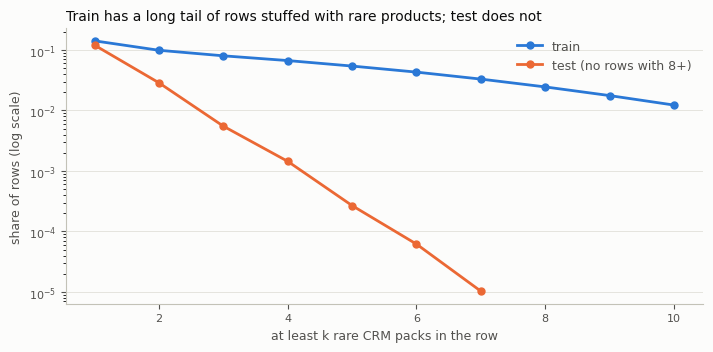

In [7]:
RARE_FREQ = 0.002
rare_crm = pack_crm & (X.mean(0) < RARE_FREQ)
rare_bil = pack_bil & (Y.mean(0) < RARE_FREQ)
rare_tr, rare_te = X[:, rare_crm].sum(1), X_test[:, rare_crm].sum(1)
rare_bil_tr = Y[:, rare_bil].sum(1)
print(f'{rare_crm.sum()} rare CRM packs | rows with >= 3 of them: train {np.mean(rare_tr >= 3):.2%}, '
      f'test {np.mean(rare_te >= 3):.2%}')

heavy = rare_tr >= 3
use = X[heavy][:, rare_crm].sum(0)
print(f'in those rows the {rare_crm.sum()} rare packs are used almost equally often: '
      f'coefficient of variation {use.std() / use.mean():.2f}; '
      f'rank correlation with their natural frequency in test {spearmanr(use, X_test[:, rare_crm].mean(0)).statistic:.2f}')
print(f'rare packs per row — not test-like rows: {rare_tr[~test_like].mean():.2f} CRM / '
      f'{rare_bil_tr[~test_like].mean():.2f} BIL; test-like rows: {rare_tr[test_like].mean():.2f} / '
      f'{rare_bil_tr[test_like].mean():.2f}')

print('\nrare CRM packs (rows) vs rare BIL items (columns) per training row — the counts move together:')
display(pd.crosstab(pd.Series(np.minimum(rare_tr, 6), name='rare CRM packs'),
                    pd.Series(np.minimum(rare_bil_tr, 6), name='rare BIL items')))


def partner_rate(mask):
    # For each rare CRM pack: how often its most associated rare BIL item appears with it.
    Xs, Ys = X[mask][:, rare_crm].astype(np.float32), Y[mask][:, rare_bil].astype(np.float32)
    n = Xs.sum(0)
    rate = (Xs.T @ Ys).max(1) / np.maximum(n, 1)
    return np.median(rate[n >= 5])


clean_rows = test_like & (rare_tr < 3)
print(f'a rare CRM pack\'s most associated rare BIL item appears with it in {partner_rate(clean_rows):.0%} of clean rows '
      f'(median), but only {partner_rate(rare_tr >= 3):.0%} of rows with 3+ rare packs')

ks = np.arange(1, 11)
share_te = np.array([np.mean(rare_te >= k) for k in ks])
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(ks, [np.mean(rare_tr >= k) for k in ks], color=BLUE, lw=2, marker='o', ms=5, label='train')
ax.plot(ks[share_te > 0], share_te[share_te > 0], color=ORANGE, lw=2, marker='o', ms=5,
        label=f'test (no rows with {ks[share_te > 0].max() + 1}+)')
ax.set_yscale('log')
style(ax, grid='y')
ax.set_xlabel('at least k rare CRM packs in the row', color=INK2)
ax.set_ylabel('share of rows (log scale)', color=INK2)
ax.set_title('Train has a long tail of rows stuffed with rare products; test does not', loc='left', color=INK, fontsize=10)
ax.legend(frameon=False, labelcolor=INK2)
plt.tight_layout()
plt.show()

Three signs point to random injection:
1. **Training has a long tail that test does not.** 8% of training customers have three or more
   rare products, against 0.55% of test customers (chart).
2. **The rare products are used almost uniformly.** Real customers do not choose products at
   random.
3. **Both sides are changed together, but with unrelated identities.** The numbers of rare
   CRM products and rare billing items rise together (table), but the usual pairing between a
   product and its billing item appears six times less often in these rows.

The impossible categories arrive with the same bursts, so we treat them as one problem. These
rows teach the model false product links. Chapter 10 examines them against the fraud
pattern the operator suspects -- products added to the CRM without billing -- and finds that most carry added billing items as well.

### The fix

- **Remove suspected-corrupted rows from training.** These are rows that are not test-like or
  carry four or more rare products, about 7% of training. They are removed from training only:
  every test customer is still scored.
- **Measure on clean-like rows.** These are test-like validation rows with fewer than three
  rare products. The definition uses CRM inputs only, and this score tracks the test score.

<a id="model"></a>
# 5. The model

Billing is close to "one product, its billing items": two customers who differ by one CRM
product usually differ by one billing item. The model therefore has one classifier per billing
item, in two stages, both trained on the cleaned training rows (unique CRM configurations with
their consensus bill):

- **Stage 1:** one LightGBM classifier per billing item on the 745 raw CRM flags: 100 trees,
  15 leaves, `min_child_samples=5`, `reg_lambda=1`, decision threshold 0.5.
- **Stage 2:** specialists for the long-tail billing items (below).

Here both stages are fitted on the seed-42 training fold, so that they can be scored on
validation.

### How the settings were chosen

Every setting was tuned on **clean-like validation EMR**, on the seed-42 split, and confirmed on
a second split (seed 7). A change was kept only if it gained at least about 0.1 points on both
splits in a paired test (both settings scored on the same resampled configurations); within
that margin, the simpler and more regularised setting wins. The tuning runs are reported here
rather than recomputed (each row is a full refit of 731 models). They were measured with the
Sprint 1 additive rules switched on, which add about 0.02 points; the final model does not use
those rules.

**1. Cleaning cut-off.** Drop training rows that are not test-like or carry at least *k* rare
CRM products (`min_child_samples` = 20 at this stage).

| *k* | Training rows dropped | Seed 42 | Seed 7 |
|---|---|---|---|
| no drop | 0% | 95.93% | 95.06% |
| 2 | 9.8% | 95.45% | — |
| 3 | 8.1% | 96.41% | — |
| **4 (chosen)** | **6.9%** | **96.57%** | **96.15%** |
| 5 | 5.8% | 96.50% | — |
| 6 | 4.9% | 96.62% | 95.80% |
| 8 | 3.4% | 96.30% | — |

Small *k* throws away real customers with rare products; large *k* keeps the corruption in.
*k* = 4–6 is a plateau, and *k* = 4 holds best on the second split. Dropping the rows (*k* = 4)
gains +0.81 points [+0.44, +1.19] on seed 42 and +1.25 [+0.91, +1.74] on seed 7 (paired 95%
intervals).

**2. Stage 1 hyperparameters** (after cleaning with *k* = 4; 100 trees and 15 leaves unless stated).

| `min_child_samples` | `reg_lambda` | Seed 42 | Seed 7 |
|---|---|---|---|
| 20 | 1 | 96.57% | 96.15% |
| 10 | 1 | 96.78% | 96.11% |
| **5 (chosen)** | **1** | **96.81%** | **96.33%** |
| 2 | 1 | 96.82% | 96.36% |
| 5 | 5 | 96.61% | 96.25% |
| 5 | 0 | 33.00% | 26.29% |
| 5, with 200 trees and 31 leaves | 1 | 96.87% | 96.39% |

- `min_child_samples` 20 → 5: +0.27 [+0.08, +0.62] and +0.20 [+0.08, +0.35] → adopted. Once
  the corrupted rows are gone, small leaves can learn genuine rare products.
- 5 → 2: −0.00 and +0.03, not significant → 5 kept (more regularised).
- `reg_lambda` must stay on: at 0, one rare billing item fires for 27% of customers.
- More trees and leaves: +0.04 and +0.05, not significant → the smaller model is kept.

**3. Decision threshold.** A lower threshold (0.45) for rare billing items gained +0.07 and
+0.10 on the two splits but only +0.03 in 5-fold cross-validation, below the 0.1-point bar set
before testing → the threshold stays at 0.5 for every item.

**4. Stage 2.** Long-tail items are those with out-of-fold F1 below 0.5 inside the training data.
Specialists use the Stage 1 settings, with the rare positives up-weighted (square root of the
class ratio, capped at 10). Stage 2 raised clean-like EMR by +0.12 [+0.07, +0.18] and +0.19
[+0.08, +0.34] points on the two splits and was positive in all five folds.

In [8]:
PARAMS = dict(n_estimators=100, num_leaves=15, learning_rate=0.1, min_child_samples=5,
              reg_lambda=1.0, verbose=-1)


def fit_one(Xf, y):
    if y.min() == y.max():
        return float(y[0])
    return lgb.LGBMClassifier(n_jobs=2, **PARAMS).fit(Xf, y)


def fit_models(Xu, Yu):
    Xf = Xu.astype(np.float32)
    return Parallel(n_jobs=8, backend='threading')(delayed(fit_one)(Xf, Yu[:, j]) for j in range(Yu.shape[1]))


def predict_proba(models, A):
    Af = A.astype(np.float32)
    one = lambda m: np.full(len(Af), m, np.float32) if isinstance(m, float) else m.predict_proba(Af)[:, 1]
    return np.column_stack(Parallel(n_jobs=8, backend='threading')(delayed(one)(m) for m in models))


def unique_configs(A, B):
    codes, _ = factorize_rows(A)
    _, first = np.unique(codes, return_index=True)
    return A[first], B[first]


def predict(models, A):
    P = predict_proba(models, A)
    return P, (P >= 0.5).astype(np.uint8)


keep = tr[test_like[tr] & (rare_tr[tr] < 4)]
Xu, Yu = unique_configs(X[keep], Y[keep])
t0 = time.time()
models = fit_models(Xu, Yu)
P_val, pred_val = predict(models, X[va])
print(f'dropped {len(tr) - len(keep):,} suspected-corrupted training rows; '
      f'fitted 731 models on {len(Xu):,} unique configurations in {time.time() - t0:.0f}s')

dropped 10,476 suspected-corrupted training rows; fitted 731 models on 43,552 unique configurations in 243s


### Stage 2: specialists for the long-tail items

About 330 billing items are almost never predicted. Before adding any model, we checked
whether they carry a learnable signal, using the training data only:

| Group of long-tail items | Items | Mean F1 with Stage 1 |
|---|---|---|
| Billed for one CRM product | 14 | 0.41 |
| Billed for a combination of 2–3 CRM products | 105 | 0.25 |
| No CRM signal; positives sit next to injected rare products | 212 | 0.01 |

The first two groups follow real CRM patterns that carry over to new customers: on validation
those patterns are right 92–93% of the time. Stage 1 under-uses them because each item has only
20 to 50 training examples. The third group looks like what is left of the random injection.
Over 90% of all long-tail positives sit on customers with at least one rare product.

**The design**
1. **Long-tail items** are the items whose out-of-fold F1 inside the training data is below
   0.5. Only training labels are used to pick them.
2. **Specialists**: one extra LightGBM per long-tail item, with the same settings as Stage 1
   but with the rare positive examples up-weighted.
3. **Add-only, and only where it is plausible.** A specialist may switch an item *on* when
   Stage 1 said no, and only for customers with at least one rare product. It never removes
   anything Stage 1 predicted.

In [9]:
def config_weights(A):
    # Rows per unique configuration, in the order returned by unique_configs.
    codes, _ = factorize_rows(A)
    _, first = np.unique(codes, return_index=True)
    return np.bincount(codes)[codes[first]].astype(np.float32)


def oof_proba(Xu_, Yu_, n_splits=5):
    # Out-of-fold Stage-1 probabilities on the training configurations (each fold = whole configurations).
    oof = np.zeros(Yu_.shape, np.float32)
    for a, b in KFold(n_splits, shuffle=True, random_state=0).split(Xu_):
        oof[b] = predict_proba(fit_models(Xu_[a], Yu_[a]), Xu_[b])
    return oof


def long_tail_labels(Yu_, oof, w):
    # Items whose row-weighted out-of-fold F1 at 0.5 is below 0.5.
    Yb, Pb = Yu_.astype(bool), oof >= 0.5
    tp, fp, fn = w @ (Yb & Pb), w @ (~Yb & Pb), w @ (Yb & ~Pb)
    f1 = np.where(tp + fp + fn > 0, 2 * tp / np.maximum(2 * tp + fp + fn, 1e-9), 1.0)
    return np.flatnonzero((Yu_.sum(0) > 0) & (f1 < 0.5))


def fit_specialists(Xu_, Yu_, labels):
    Xf = Xu_.astype(np.float32)

    def one(j):
        y = Yu_[:, j]
        spw = float(np.clip(np.sqrt((len(y) - y.sum()) / max(y.sum(), 1)), 1, 10))
        return lgb.LGBMClassifier(n_jobs=2, scale_pos_weight=spw, **PARAMS).fit(Xf, y)
    return Parallel(n_jobs=8, backend='threading')(delayed(one)(j) for j in labels)


def two_stage(pred1, specialists, labels, A):
    P2 = predict_proba(specialists, A)
    gate = (A[:, rare_crm].sum(1) > 0)[:, None]           # customers with >= 1 rare CRM product
    out = pred1.copy()
    sub_ = out[:, labels]
    out[:, labels] = np.where((sub_ == 0) & (P2 >= 0.5) & gate, 1, sub_)   # add-only
    return out


t0 = time.time()
lt_val = long_tail_labels(Yu, oof_proba(Xu, Yu), config_weights(X[keep]))
spec_val = fit_specialists(Xu, Yu, lt_val)
pred_val2 = two_stage(pred_val, spec_val, lt_val, X[va])
print(f'{len(lt_val)} long-tail items (training OOF F1 < 0.5); 5 out-of-fold fits + {len(lt_val)} specialists '
      f'in {time.time() - t0:.0f}s')

332 long-tail items (training OOF F1 < 0.5); 5 out-of-fold fits + 332 specialists in 1367s


### Validation score of the final model

In [10]:
Yv = Y[va]
clean_like = test_like & (rare_tr < 3)
for name, m in [('all validation rows', np.ones(len(va), bool)), ('test-like rows', test_like[va]),
                ('clean-like rows (primary)', clean_like[va])]:
    emr = (pred_val2[m] == Yv[m]).all(1).mean()
    print(f'{name:28s} {m.sum():6,} rows   EMR {emr:.2%}')

cl = clean_like[va]
yt, yp = Yv[cl], pred_val2[cl]          # final model: Stage 1 + Stage 2
active = yt.sum(0) > 0
report = pd.Series({
    'EMR': (yt == yp).all(1).mean(),
    'bit accuracy': (yt == yp).mean(),
    'F1 micro': f1_score(yt, yp, average='micro'),
    'F1 macro (columns with positives)': f1_score(yt[:, active], yp[:, active], average='macro', zero_division=0),
    'precision micro': precision_score(yt, yp, average='micro'),
    'recall micro': recall_score(yt, yp, average='micro'),
})
display(report.to_frame('clean-like validation').style.format('{:.4f}'))
cm = pd.DataFrame([[int(((yt == 1) & (yp == 1)).sum()), int(((yt == 1) & (yp == 0)).sum())],
                   [int(((yt == 0) & (yp == 1)).sum()), int(((yt == 0) & (yp == 0)).sum())]],
                  index=['actual 1', 'actual 0'], columns=['predicted 1', 'predicted 0'])
display(cm.style.format('{:,}'))
err = (yt != yp).sum(1)
r = rare_tr[va][cl]
print(f'EMR on clean-like rows with no rare pack: {np.mean(err[r == 0] == 0):.2%} | '
      f'with 1–2 rare packs ({np.mean(r > 0):.1%} of rows): {np.mean(err[r > 0] == 0):.2%}')

all validation rows          36,385 rows   EMR 88.78%
test-like rows               35,818 rows   EMR 90.18%
clean-like rows (primary)    33,261 rows   EMR 96.92%


,clean-like validation
EMR,0.9692
bit accuracy,0.9998
F1 micro,0.9958
F1 macro (columns with positives),0.5483
precision micro,0.9985
recall micro,0.9931


,predicted 1,predicted 0
actual 1,"474,467","3,319"
actual 0,715,"23,835,290"


EMR on clean-like rows with no rare pack: 99.17% | with 1–2 rare packs (7.1% of rows): 67.25%


On clean-like validation rows, **96.92%** of customers are exactly right. Customers without a
rare product are 99.2% exact, and almost all remaining errors sit in the 7% of customers with
one or two rare products. Most errors are **missed** billing items: 3,319 false negatives
against 715 false positives.

### Why exact match is harsh, and why errors cluster

With 731 items per customer, even a tiny error rate per item would sink EMR if the errors were
spread evenly.

In [11]:
bit_err = (yt != yp).mean()
print(f'bit error rate {bit_err:.2e} -> {bit_err * 731:.3f} wrong bits per customer on average')
print(f'EMR if errors were independent across bits: (1 - e)^731 = {(1 - bit_err) ** 731:.2%} | actual EMR {np.mean(err == 0):.2%}')
print(f'{np.mean(err >= 2):.2%} of customers carry {err[err >= 2].sum() / err.sum():.0%} of all wrong bits')

bit error rate 1.66e-04 -> 0.121 wrong bits per customer on average
EMR if errors were independent across bits: (1 - e)^731 = 88.58% | actual EMR 96.92%
2.17% of customers carry 92% of all wrong bits


If errors were independent, EMR would be 88.6%. It is 96.9% because errors cluster: 2.2% of
customers carry 92% of the wrong items. Improving EMR is about *which customers* fail, not
about accuracy per item.

### How certain is the validation score?

Customers with the same CRM configuration share both the prediction and the target, so they
are not independent. We therefore resample whole configurations, not rows.

In [12]:
def config_bootstrap(groups_, values, b=2000, seed=0):
    codes, _ = pd.factorize(groups_)
    s, n = np.bincount(codes, weights=values), np.bincount(codes)
    idx = np.random.default_rng(seed).integers(0, len(s), size=(b, len(s)))
    boot = s[idx].sum(1) / n[idx].sum(1)
    return s.sum() / n.sum(), boot.std(), np.percentile(boot, [2.5, 97.5])


ok_row = (err == 0).astype(float)
m, se, (lo, hi) = config_bootstrap(groups[va][cl], ok_row)
print(f'clean-like validation EMR {m:.2%} | configuration-level SE {se * 100:.2f} pt '
      f'(a naive row-level SE would say {np.sqrt(m * (1 - m) / len(ok_row)) * 100:.2f}) | 95% CI [{lo:.2%}, {hi:.2%}]')

clean-like validation EMR 96.92% | configuration-level SE 0.37 pt (a naive row-level SE would say 0.09) | 95% CI [96.13%, 97.57%]


The interval is wide (about ±0.7 points) because a few very common configurations weigh
heavily. Five-fold cross-validation, grouped by configuration, gives **96.99% ± 0.20** for the final
model. The test set, where every customer is its own configuration, gives the precise final
number.

### Which customers fail?

In [13]:
crm_arr = np.array(crm_cols)
Xcl = X[va][cl]
seg_rows = []


def segment(name, labels):
    for lab in pd.unique(labels):
        mm = labels == lab
        seg_rows.append({'segment': name, 'value': lab, 'customers': int(mm.sum()), 'EMR': np.mean(err[mm] == 0),
                         'share of wrong customers': (err[mm] > 0).sum() / max((err > 0).sum(), 1)})


for g in ('SUBSCRIBER_STATUS', 'SUBSCRIBER_TYPE'):
    cols = [i for i, c in enumerate(crm_cols) if c.startswith(f'CRM_{g}_ORIG_')]
    segment(g.lower(), np.array([c.split('_ORIG_')[1] for c in crm_arr[cols]])[Xcl[:, cols].argmax(1)])
segment('CRM products per customer', pd.cut(Xcl[:, pack_crm].sum(1), [0, 10, 15, 20, 1000],
                                             labels=['<= 10', '11-15', '16-20', '21+']).astype(str))
segment('rare CRM products', np.where(rare_tr[va][cl] > 0, '1-2', '0'))
seg = pd.DataFrame(seg_rows).sort_values(['segment', 'customers'], ascending=[True, False]).set_index(['segment', 'value'])
display(seg.style.format({'EMR': '{:.2%}', 'share of wrong customers': '{:.1%}', 'customers': '{:,}'}))

Product mix matters, not status or contract type. Customers with one or two rare products (7%
of rows) account for three quarters of the wrong customers, and EMR also drops for very large
baskets of 16 or more products.

### Items the model cannot vouch for

In [14]:
tp_c = ((yt == 1) & (yp == 1)).sum(0)
fp_c = ((yt == 0) & (yp == 1)).sum(0)
fn_c = ((yt == 1) & (yp == 0)).sum(0)
f1_c = np.where(tp_c + fp_c + fn_c > 0, 2 * tp_c / np.maximum(2 * tp_c + fp_c + fn_c, 1), np.nan)
weak = f1_c < 0.5
has_weak = yt[:, weak].any(1)
print(f'billing items with validation F1 < 0.5: {np.nansum(weak)} of 731 columns, but only '
      f'{yt[:, weak].sum() / yt.sum():.2%} of all billed items')
print(f'customers billed for at least one such item: {has_weak.mean():.2%} | their EMR {np.mean(err[has_weak] == 0):.1%} '
      f'vs {np.mean(err[~has_weak] == 0):.2%} for everyone else')

billing items with validation F1 < 0.5: 309 of 731 columns, but only 0.33% of all billed items
customers billed for at least one such item: 2.32% | their EMR 9.2% vs 99.00% for everyone else


309 billing items have a validation F1 below 0.5. Together they are only 0.33% of everything
billed, but 2.3% of customers have at least one of them, and those customers are almost never
exactly right. This is also why **macro F1**, which weights every item equally, is only about
0.55 while micro F1 is 0.996. These are the long-tail items: Stage 2 already recovers part of
them, and the rest has no CRM signal.

<a id="business"></a>
# 6. Business use: catching provisioning errors

The brief's goal is to catch provisioning errors. The model predicts the bill a customer
*should* have; comparing it with the bill they *actually* have gives a review queue.

**The rule.** Flag a customer when any actual billing item disagrees with the prediction. Then
sort the flagged customers:
1. customers with rare products go last, because that is where the model itself is weakest;
2. among the rest, fewer disagreeing items come first: real provisioning errors usually involve
   one or two items, while a model mistake often spans several.

**How we evaluate it.** In the validation data we know some real errors: customers whose bill
differs from the consensus bill of their CRM configuration. Errors in configurations seen only
once cannot be confirmed, so the precision shown is a lower bound.

The rule was designed on this split (seed 42), so a second split (seed 7) is the honest check.

33,261 customers with a clean-looking CRM record; known provisioning errors among them: 221 (0.66%); flagged by the rule: 3.8%


,"alerts per 10,000",known errors caught,precision (lower bound),lift vs random review
review the top,,,,
0.5% of customers,50,33%,44%,66x
1.0% of customers,100,73%,49%,73x
2.0% of customers,200,92%,31%,46x
3.8% of customers,377,92%,16%,25x


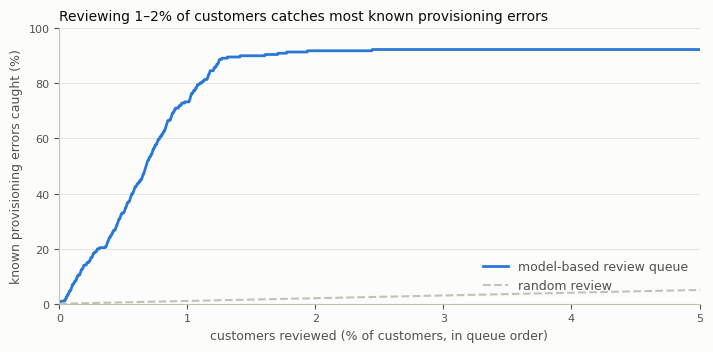

separately, 8.6% of validation customers have a CRM record that itself looks corrupted (impossible categories or bursts of rare products) -> a CRM data-quality queue


In [15]:
Y_obs = Y_raw[va][cl]                    # what the billing system actually contains
e = noisy[va][cl]                        # known provisioning errors
disagree = np.abs(P_val[cl] - Y_obs) > 0.5
flagged = disagree.any(1)
n_items = disagree.sum(1)
rare_cust = rare_tr[va][cl] > 0
key = (~flagged) * 1000 + rare_cust * 100 + n_items      # unflagged last; rare-product customers last; fewer items first
order = np.lexsort((np.arange(len(e)), key))
caught = np.cumsum(e[order]) / max(e.sum(), 1)
reviewed = np.arange(1, len(e) + 1) / len(e)
base = e.mean()
print(f'{len(e):,} customers with a clean-looking CRM record; known provisioning errors among them: '
      f'{e.sum()} ({base:.2%}); flagged by the rule: {flagged.mean():.1%}')
rows = []
for share in (0.005, 0.01, 0.02, flagged.mean()):
    k = int(share * len(e))
    hit = e[order[:k]].sum()
    rows.append({'review the top': f'{share:.1%} of customers', 'alerts per 10,000': round(share * 10_000),
                 'known errors caught': f'{hit / e.sum():.0%}', 'precision (lower bound)': f'{hit / k:.0%}',
                 'lift vs random review': f'{hit / k / base:.0f}x'})
display(pd.DataFrame(rows).set_index('review the top'))

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(reviewed * 100, caught * 100, color=BLUE, lw=2, label='model-based review queue')
ax.plot([0, 100], [0, 100], color=AXIS, lw=1.5, ls='--', label='random review')
ax.set_xlim(0, 5)
ax.set_ylim(0, 100)
style(ax, grid='y')
ax.set_xlabel('customers reviewed (% of customers, in queue order)', color=INK2)
ax.set_ylabel('known provisioning errors caught (%)', color=INK2)
ax.set_title('Reviewing 1–2% of customers catches most known provisioning errors', loc='left', color=INK, fontsize=10)
ax.legend(frameon=False, labelcolor=INK2, loc='lower right')
plt.tight_layout()
plt.show()

flag_corrupt = ~clean_like[va]
print(f'separately, {flag_corrupt.mean():.1%} of validation customers have a CRM record that itself looks corrupted '
      f'(impossible categories or bursts of rare products) -> a CRM data-quality queue')

On this split, reviewing the top 2% of customers catches 92% of the known errors, about 46
times better than reviewing customers at random.

### How reliable is the detector?

Two extra checks: a confidence interval on that recall, and **synthetic errors**. The known
errors are only small deviations in repeated configurations, so we also corrupt the bills of
clean customers ourselves (one to three missing or extra items) and see what the queue
catches.

In [16]:
n_cl = len(e)
codes_cl, _ = pd.factorize(groups[va][cl])


def ratio_ci(num, den, b=2000, seed=0):
    sn, sd = np.bincount(codes_cl, weights=num), np.bincount(codes_cl, weights=den)
    idx = np.random.default_rng(seed).integers(0, len(sn), size=(b, len(sn)))
    return np.percentile(sn[idx].sum(1) / np.maximum(sd[idx].sum(1), 1), [2.5, 97.5])


top2 = np.zeros(n_cl, bool)
top2[order[:int(0.02 * n_cl)]] = True
lo, hi = ratio_ci((e & top2).astype(float), e.astype(float))
print(f'1) known errors caught in the top 2%: {(e & top2).sum() / e.sum():.0%} '
      f'(95% CI {lo:.0%}-{hi:.0%}, resampling configurations)')


def queue_order(D):
    dis = D > 0.5
    k_ = (~dis.any(1)) * 1000 + rare_cust * 100 + dis.sum(1)
    return np.lexsort((np.arange(len(D)), k_))


rng_s = np.random.default_rng(1)
D0 = np.abs(P_val[cl] - Y_obs)
clean_idx = np.flatnonzero(~e)
item_prev = Y[keep].mean(0)
cfg_size = pd.Series(codes_cl).map(pd.Series(codes_cl).value_counts()).to_numpy()
unique_cfg = cfg_size == 1
syn = []
for kind in ('missing item', 'extra item'):
    for k in (1, 2, 3):
        res_ = []
        for _ in range(3):
            S = rng_s.choice(clean_idx, size=int(0.0065 * n_cl), replace=False)
            Ymod = Y_obs[S].copy()
            for r_ in range(len(S)):
                pool = np.flatnonzero(Ymod[r_] == (1 if kind == 'missing item' else 0))
                pick = (rng_s.choice(pool, size=min(k, len(pool)), replace=False) if kind == 'missing item'
                        else rng_s.choice(pool, size=k, replace=False, p=item_prev[pool] / item_prev[pool].sum()))
                Ymod[r_, pick] = 1 - Ymod[r_, pick]
            Dm = D0.copy()
            Dm[S] = np.abs(P_val[cl][S] - Ymod)
            in_top = np.zeros(n_cl, bool)
            in_top[queue_order(Dm)[:int(0.02 * n_cl)]] = True
            res_.append((in_top[S].mean(), in_top[S][unique_cfg[S]].mean(), in_top[S][~unique_cfg[S]].mean()))
        a = np.mean(res_, 0)
        syn.append({'injected error': kind, 'items': k, 'caught in top 2%': f'{a[0]:.0%}',
                    'unique configuration': f'{a[1]:.0%}', 'repeated configuration': f'{a[2]:.0%}'})
print(f'2) synthetic errors injected into {int(0.0065 * n_cl)} clean customers (3 repetitions each); '
      f'{unique_cfg[clean_idx].mean():.0%} of clean customers here have a unique configuration:')
display(pd.DataFrame(syn).set_index(['injected error', 'items']))

1) known errors caught in the top 2%: 92% (95% CI 86%-96%, resampling configurations)


2) synthetic errors injected into 216 clean customers (3 repetitions each); 26% of clean customers here have a unique configuration:


caught in top 2% unique configuration repeated configuration
injected error items                                                             
missing item   1                  94%                  81%                    99%
               2                  92%                  81%                    97%
               3                  94%                  80%                    98%
extra item     1                  92%                  77%                    98%
               2                  94%                  80%                    98%
               3                  91%                  76%                    97%

- **On the honest split (seed 7)**, the top 2% catches 83% of the known errors (95% CI 73–92%,
  from the project scripts); on this split it is 92%. Either way, about 40 times better than
  random review.
- **Synthetic errors** are caught about 92% of the time within a 2% review budget, whether one,
  two or three items are wrong. The weak spot is customers with a unique configuration, which
  is every test customer: there about 80% are caught.

**In production** this would run as a nightly batch with two queues: the billing check above,
whose size is set by the review budget, and a CRM data-quality queue for records with
impossible categories or bursts of rare products. Thresholds are recomputed from the live CRM
base, the model is retrained monthly or when new products launch, and alert volume and the
confirmed-error rate are monitored.

<a id="shap"></a>
# 7. Explainability: what did the model learn?

We use SHAP values (LightGBM's built-in TreeSHAP) on clean-like validation customers. For each
billing item we ask which CRM product drives it, and compare the answer with an **expected
driver** computed without the model: the CRM product that co-occurs most with the item in the
training data. Agreement between the two is therefore a real check.

In [17]:
Xf, Yf = Xu.astype(np.float32), Yu.astype(np.float32)
inter = Xf.T @ Yf
cooc = np.minimum(inter / np.maximum(Xf.sum(0)[:, None], 1), inter / np.maximum(Yf.sum(0)[None, :], 1))
expected, expected_score = cooc.argmax(0), cooc.max(0)

rng = np.random.default_rng(0)
Xv = X[va].astype(np.float32)
cl_idx = np.flatnonzero(cl)
imp = np.zeros((len(bil_cols), len(crm_cols)), np.float32)
pos_rows = {}
t0 = time.time()
for j, m in enumerate(models):
    rows = cl_idx[(Yv[cl_idx, j] == 1) | (pred_val[cl_idx, j] == 1)]
    if len(rows) > 400:
        rows = rng.choice(rows, 400, replace=False)
    if len(rows) == 0:
        rows = rng.choice(cl_idx, 400, replace=False)
    pos_rows[j] = Xv[rows]
    if not isinstance(m, float):
        imp[j] = np.abs(m.booster_.predict(pos_rows[j], pred_contrib=True)[:, :-1]).mean(0)
print(f'SHAP for 731 models in {time.time() - t0:.0f}s')

top = imp.argmax(1)
conc = imp.max(1) / np.maximum(imp.sum(1), 1e-12)
tp_, fp_, fn_ = (((yt == 1) & (yp == 1)).sum(0), ((yt == 0) & (yp == 1)).sum(0), ((yt == 1) & (yp == 0)).sum(0))
f1_col = np.where(tp_ + fp_ + fn_ > 0, 2 * tp_ / np.maximum(2 * tp_ + fp_ + fn_, 1), np.nan)
in_top3 = np.array([expected[j] in np.argsort(-imp[j])[:3] for j in range(len(bil_cols))])
strong = expected_score >= 0.8
display(pd.DataFrame([
    {'BIL columns': 'with a clear expected driver (score >= 0.8)', 'count': strong.sum(),
     'top SHAP driver = expected': (top == expected)[strong].mean(), 'expected in SHAP top 3': in_top3[strong].mean()},
    {'BIL columns': 'without one', 'count': (~strong).sum(),
     'top SHAP driver = expected': (top == expected)[~strong].mean(), 'expected in SHAP top 3': in_top3[~strong].mean()},
]).set_index('BIL columns').style.format({'top SHAP driver = expected': '{:.1%}', 'expected in SHAP top 3': '{:.1%}'}))

SHAP for 731 models in 14s


,count,top SHAP driver = expected,expected in SHAP top 3
BIL columns,,,
with a clear expected driver (score >= 0.8),233,95.7%,99.1%
without one,498,46.4%,50.2%


Where a clear product-to-billing link exists (233 items), the model's main driver is the
expected one 96% of the time, and it is in the top three 99% of the time. The other 498 items
have no single dominant cause, so this check does not apply to them.

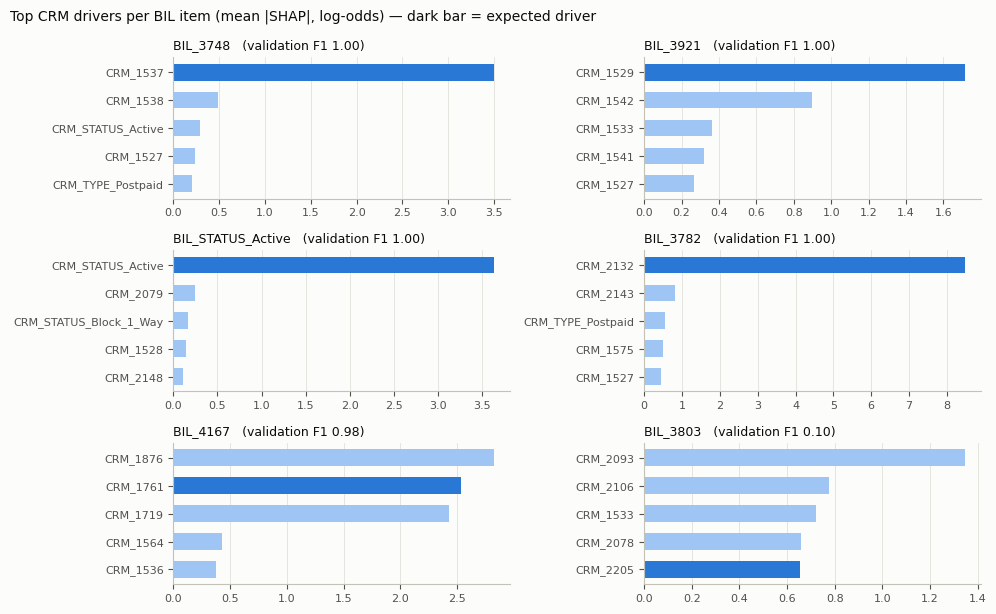

In [18]:
SELECTED = ['BIL_3748_PACK', 'BIL_3921_PACK', 'BIL_SUBSCRIBER_STATUS_ORIG_Active', 'BIL_3782_PACK',
            'BIL_4167_PACK', 'BIL_3803_PACK']
short = lambda c: c.replace('_PACK', '').replace('SUBSCRIBER_STATUS_ORIG_', 'STATUS_').replace('SUBSCRIBER_TYPE_ORIG_', 'TYPE_')
crm_arr = np.array(crm_cols)
fig, axes = plt.subplots(3, 2, figsize=(10, 6.2))
for ax, b in zip(axes.ravel(), SELECTED):
    j = bil_cols.index(b)
    order = np.argsort(-imp[j])[:5][::-1]
    ax.barh([short(crm_arr[f]) for f in order], imp[j, order],
            color=[BLUE if f == expected[j] else LIGHT_BLUE for f in order], height=0.6)
    style(ax)
    ax.set_title(f'{short(b)}   (validation F1 {f1_col[j]:.2f})', loc='left', color=INK, fontsize=9)
fig.suptitle('Top CRM drivers per BIL item (mean |SHAP|, log-odds) — dark bar = expected driver',
             x=0.01, ha='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

Some examples from the chart: `BIL_3748` is driven by `CRM_1537`, the billing `Active` status
by the CRM `Active` status, and the rare `BIL_3782` by the rare `CRM_2132`. `BIL_4167` is billed
for any of three CRM products, which is the many-to-one mapping described in the brief, and the
model handles it. `BIL_3803` has no dominant cause, and its F1 is low.

### Where the errors come from

,columns,median_F1
band,,
≤ 0.3 (diffuse),299,0.00
0.3–0.5,116,0.69
0.5–0.7,148,0.95
> 0.7 (one clear driver),168,0.99


Spearman(concentration, F1) over 727 columns: +0.87


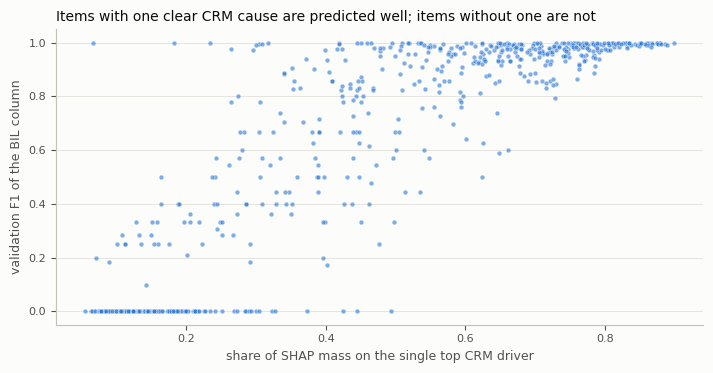

noise check: median SHAP share on rare CRM packs 1.1%; 119 columns lean > 50% on rare packs, and for 100% of them that rare pack is the column's own expected driver


In [19]:
ok = ~np.isnan(f1_col)
bands = pd.cut(conc, [0, 0.3, 0.5, 0.7, 1.0], labels=['≤ 0.3 (diffuse)', '0.3–0.5', '0.5–0.7', '> 0.7 (one clear driver)'])
summary = pd.DataFrame({'band': bands, 'f1': f1_col}).groupby('band', observed=True).agg(
    columns=('f1', 'size'), median_F1=('f1', 'median'))
display(summary.style.format({'median_F1': '{:.2f}'}))
print(f'Spearman(concentration, F1) over {ok.sum()} columns: {spearmanr(conc[ok], f1_col[ok]).statistic:+.2f}')

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.scatter(conc[ok], f1_col[ok], s=12, color=BLUE, alpha=0.6, edgecolors=SURFACE, linewidths=0.5)
style(ax, grid='y')
ax.set_xlabel('share of SHAP mass on the single top CRM driver', color=INK2)
ax.set_ylabel('validation F1 of the BIL column', color=INK2)
ax.set_title('Items with one clear CRM cause are predicted well; items without one are not',
             loc='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

share_rare = imp[:, rare_crm].sum(1) / np.maximum(imp.sum(1), 1e-12)
hi = share_rare > 0.5
print(f'noise check: median SHAP share on rare CRM packs {np.median(share_rare):.1%}; '
      f'{hi.sum()} columns lean > 50% on rare packs, and for {np.mean(rare_crm[expected[hi]]):.0%} of them '
      f'that rare pack is the column\'s own expected driver')

- **Items with one clear cause are predicted well; diffuse items are not.** How concentrated an
  item's explanation is predicts its F1 (rank correlation +0.87).
- **The model does not learn the injected noise.** When an item leans on a rare product, it is
  always that item's own expected product, never an unrelated one.

### One error, explained

In [20]:
err_rows = np.flatnonzero(cl & ((pred_val != Yv).sum(1) == 1))
cands = [(i, int(np.flatnonzero(pred_val[i] != Yv[i])[0])) for i in err_rows]
# Prefer a missed item whose expected driver (a rare product) is present; else any missed item.
example = next(((i, j) for i, j in cands if Yv[i, j] == 1 and Xv[i, expected[j]] == 1 and rare_crm[expected[j]]),
               next((i, j) for i, j in cands if Yv[i, j] == 1))
i, j = example
contrib = models[j].booster_.predict(Xv[i:i + 1], pred_contrib=True)[0]
present = np.flatnonzero(Xv[i] == 1)
order = present[np.argsort(-np.abs(contrib[present]))][:5]
print(f'{bil_cols[j]} is billed for this customer, but the model predicted p = {P_val[i, j]:.2f} (< 0.5)')
print(f'baseline log-odds {contrib[-1]:+.2f}; largest contributions from the CRM columns the customer has:')
for f in order:
    print(f'   {crm_cols[f]:34s} {contrib[f]:+6.2f}' + ('   <- expected driver (rare product)' if f == expected[j] else ''))

BIL_4139_PACK is billed for this customer, but the model predicted p = 0.23 (< 0.5)
baseline log-odds -8.44; largest contributions from the CRM columns the customer has:
   CRM_1727_PACK                       +7.60   <- expected driver (rare product)
   CRM_1570_PACK                       +0.63
   CRM_1608_PACK                       +0.55
   CRM_1525_PACK                       -0.50
   CRM_1606_PACK                       -0.46


The model found the right cause: the rare CRM product pushes strongly towards billing the item.
With only a handful of clean training examples, though, the evidence stops short of the 0.5
threshold. This is the typical remaining error, and it is what Stage 2 targets.

<a id="submission"></a>
# 8. Final training and submission

The frozen model is re-fitted on all of `train.csv` (minus the suspected-corrupted rows) and
applied to the test set. The list of long-tail items for Stage 2 is rebuilt from the training
data alone.

In [21]:
keep_all = test_like & (rare_tr < 4)
Xa, Ya = unique_configs(X[keep_all], Y[keep_all])
t0 = time.time()
final_models = fit_models(Xa, Ya)
_, pred_test1 = predict(final_models, X_test)
print(f'Stage 1: dropped {(~keep_all).sum():,} rows ({(~keep_all).mean():.1%}); trained on {len(Xa):,} unique '
      f'configurations in {time.time() - t0:.0f}s')

t0 = time.time()
lt_all = long_tail_labels(Ya, oof_proba(Xa, Ya), config_weights(X[keep_all]))
final_spec = fit_specialists(Xa, Ya, lt_all)
pred_test = two_stage(pred_test1, final_spec, lt_all, X_test)
added = pred_test != pred_test1
print(f'Stage 2: {len(lt_all)} long-tail items (training OOF F1 < 0.5); {int(added.sum())} billing items added '
      f'for {int(added.any(1).sum())} test customers [{time.time() - t0:.0f}s]')

sub = pd.DataFrame({'MSISDN': msisdn_test, 'Bill_Conf': [''.join(r) for r in pred_test.astype(str)]})
assert len(sub) == 97_100 and sub.notna().all().all() and sub['MSISDN'].is_unique
assert sub['Bill_Conf'].str.len().eq(731).all() and sub['Bill_Conf'].str.fullmatch('[01]+').all()
os.makedirs(OUT, exist_ok=True)
sub.to_csv(f'{OUT}/submission.csv', index=False)
print('written data/derived/submission.csv:', sub.shape)
sub.head(3)

Stage 1: dropped 13,131 rows (7.0%); trained on 54,387 unique configurations in 472s


Stage 2: 332 long-tail items (training OOF F1 < 0.5); 787 billing items added for 655 test customers [2064s]


written data/derived/submission.csv: (97100, 2)


,MSISDN,Bill_Conf
0,db67b03cf9fb8ea96077cd34c7a28139,10000000000000000000000000000000000000000000000000000000000000000000000101100001010001...
1,2ac0d310d5cf1a96587af614d37b8b54,10000000001000000000000000000001000000000000000000000000000000000000000001100011000001...
2,a8f289fbd263794ac74059a18c1d10a5,11000001101111000000000000000000000100000000000000000000000000000000000000000000000000...


Stage 2 adds 787 billing items for 655 of the 97,100 test customers. Everything else comes
from Stage 1.

<a id="test"></a>
# 9. Test results

The model is now frozen. Only at this point is `solution.csv` read, to score the submission. It
was never used for training or for any modelling choice.

In [22]:
sol = pd.read_csv(f'{DATA}/solution.csv', dtype=str)
m = sub.merge(sol, on='MSISDN', suffixes=('', '_true'))
assert len(m) == len(sub) == len(sol) and (m['MSISDN'].to_numpy() == msisdn_test).all()
to_bits = lambda s: np.array([np.frombuffer(x.encode(), np.uint8) - 48 for x in s])
Yt_test, Yp_test = to_bits(m['Bill_Conf_true']), to_bits(m['Bill_Conf'])
wrong = (Yt_test != Yp_test).sum(1)
test_emr = np.mean(wrong == 0)
display(pd.Series({
    'test EMR': f'{test_emr:.2%}',
    'rows exactly right': f'{(wrong == 0).sum():,} of {len(wrong):,}',
    'rows 1 bit off': f'{np.mean(wrong == 1):.2%}',
    'rows 2+ bits off': f'{np.mean(wrong >= 2):.2%}',
    'bit accuracy': f'{(Yt_test == Yp_test).mean():.5%}',
    'F1 micro': f'{f1_score(Yt_test, Yp_test, average="micro"):.4f}',
}).to_frame('test (solution.csv)'))

# Every test row is its own CRM configuration, so a plain binomial interval is appropriate here.
print(f'distinct CRM configurations in test: {factorize_rows(X_test)[1]:,} of {len(X_test):,} rows')
half = 1.96 * np.sqrt(test_emr * (1 - test_emr) / len(wrong))
print(f'95% confidence interval: [{test_emr - half:.2%}, {test_emr + half:.2%}] (±{half * 100:.2f} pt)')
act_t = Yt_test.sum(0) > 0
f1m = lambda Pr: f1_score(Yt_test[:, act_t], Pr[:, act_t], average='macro', zero_division=0)
print(f'test macro F1 (items with a positive): {f1m(Yp_test):.4f}')
be = (Yt_test != Yp_test).mean()
print(f'bit error rate {be:.2e}: EMR if errors were independent {(1 - be) ** 731:.2%} vs actual {test_emr:.2%}')

,test (solution.csv)
test EMR,97.51%
rows exactly right,"94,681 of 97,100"
rows 1 bit off,1.91%
rows 2+ bits off,0.58%
bit accuracy,99.99465%
F1 micro,0.9987


distinct CRM configurations in test: 97,100 of 97,100 rows
95% confidence interval: [97.41%, 97.61%] (±0.10 pt)


test macro F1 (items with a positive): 0.7693
bit error rate 5.35e-05: EMR if errors were independent 96.17% vs actual 97.51%


- **Test EMR: 97.51%** (95% CI 97.41–97.61).
- Test macro F1 is 0.77.
- 1.9% of customers are off by a single item, and 0.6% by two or more.

<a id="fraud"></a>
# 10. Fraud detection: products added to the CRM without billing


The model of Chapter 5 predicts the *correct* bill. The fraud pattern is the opposite
view: a CRM product that **should** produce a billing item, but the billing item is missing. Two
steps:

1. **Data rule.** Learn which billing item(s) each CRM product produces, then flag customers who
   hold the product but have none of its billing items.
2. **CRM-only detector.** Learn to recognise flagged customers from the CRM alone, so that
   customers without billing data, such as the test set, can be scored.

`solution.csv` is not used in this chapter. Test *inputs* are scored in Section 10.2.

### 10.1 Data rule: a product is in the CRM but its billing items are missing

On the rows kept for training, CRM product *p* is **billed as** item *b* when at least 80% of
its customers have *b* and *b* is at least three times more frequent with *p* than overall
(products with at least 30 customers).

495 CRM products with at least 30 kept customers; 293 have a clear billing item ("billable")
customers with at least one billable product that is not billed: 16,237 (8.7% of train)
  among the rows removed as suspected-corrupted in Chapter 4: 92.4% (12,135 of 13,131)
  among the rows kept for training: 2.4% (4,102)


,kept for training,removed in Chapter 4,total
pattern,,,
CRM extra + billing extra,3351,11553,14904
"CRM extra, billing unchanged",751,582,1333
total,4102,12135,16237


customers with the product unbilled, per billable product: mean 179, sd 31, range 104–241, while products have 250–52,696 customers


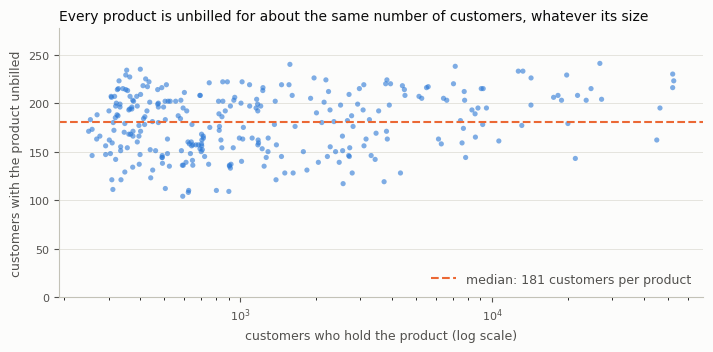

In [23]:
kept_rows = test_like & (rare_tr < 4)                     # the rows kept for training (Chapter 5)
Xk, Yk = X[kept_rows].astype(np.float32), Y_raw[kept_rows].astype(np.float32)
n_p = Xk.sum(0)
conf = (Xk.T @ Yk) / np.maximum(n_p, 1)[:, None]          # P(item | product)
lift = conf / np.maximum(Yk.mean(0), 1e-9)[None, :]
billed_as = (conf >= 0.8) & (lift >= 3) & (n_p >= 30)[:, None] & pack_crm[:, None]
billable = np.flatnonzero(billed_as.any(1))
del Xk, Yk

# A billable product is active, but none of its billing items is billed.
unbilled = np.zeros(X.shape, bool)
for p in billable:
    unbilled[:, p] = (X[:, p] == 1) & (Y_raw[:, billed_as[p]].sum(1) == 0)
n_unbilled = unbilled.sum(1)
suspect = n_unbilled > 0

# The reverse: billed items that no CRM product of the customer is billed as.
orphan = np.zeros(len(X), int)
for b in np.flatnonzero(billed_as.any(0) & pack_bil):
    orphan += (Y_raw[:, b] == 1) & (X[:, billed_as[:, b]].max(1) == 0)

print(f'{(pack_crm & (n_p >= 30)).sum()} CRM products with at least 30 kept customers; '
      f'{len(billable)} have a clear billing item ("billable")')
print(f'customers with at least one billable product that is not billed: {suspect.sum():,} '
      f'({suspect.mean():.1%} of train)')
print(f'  among the rows removed as suspected-corrupted in Chapter 4: {suspect[~kept_rows].mean():.1%} '
      f'({suspect[~kept_rows].sum():,} of {(~kept_rows).sum():,})')
print(f'  among the rows kept for training: {suspect[kept_rows].mean():.1%} ({suspect[kept_rows].sum():,})')
pattern = np.where(orphan == 0, 'CRM extra, billing unchanged', 'CRM extra + billing extra')
display(pd.crosstab(pd.Series(pattern[suspect], name='pattern'),
                    pd.Series(np.where(kept_rows[suspect], 'kept for training', 'removed in Chapter 4'), name=''),
                    margins=True, margins_name='total'))

per_pack, holders = unbilled[:, billable].sum(0), X[:, billable].sum(0)
print(f'customers with the product unbilled, per billable product: mean {per_pack.mean():.0f}, '
      f'sd {per_pack.std():.0f}, range {per_pack.min()}–{per_pack.max()}, '
      f'while products have {holders.min():,}–{holders.max():,} customers')
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.scatter(holders, per_pack, s=14, color=BLUE, alpha=0.6, edgecolors='none')
ax.axhline(np.median(per_pack), color=ORANGE, lw=1.5, ls='--',
           label=f'median: {np.median(per_pack):.0f} customers per product')
ax.set_xscale('log')
ax.set_ylim(0, per_pack.max() * 1.15)
style(ax, grid='y')
ax.set_xlabel('customers who hold the product (log scale)', color=INK2)
ax.set_ylabel('customers with the product unbilled', color=INK2)
ax.set_title('Every product is unbilled for about the same number of customers, whatever its size',
             loc='left', color=INK, fontsize=10)
ax.legend(frameon=False, labelcolor=INK2, loc='lower right')
plt.tight_layout()
plt.show()

- **The suspected-corrupted rows of Chapter 4 are these customers.** Almost all the rows removed
  before training hold at least one product that is not billed. Removing them was right for
  predicting the *correct* bill, but they are the answer to the fraud question.
- **No single product was targeted.** A genuine billing exception would grow with the number of
  customers holding the product. Instead, every product is unbilled for roughly the same number
  of customers, from products with a few dozen customers to products with tens of thousands. It
  looks as if a fixed number of customers was altered for every product.
- **Usually both sides were changed.** Most flagged customers also carry billing items that no
  CRM product explains. A minority show the pure pattern: one CRM product too many, billing
  otherwise unchanged.

### 10.2 CRM-only detector: scoring customers without billing data

Fraud is visible only by comparing CRM and billing, and `test.csv` has no billing. Can a flagged
customer be recognised from the CRM alone? One LightGBM classifier is trained on the CRM columns
plus the number of rare products and of products, with the rule's flags as labels. It is
evaluated out-of-fold (5 folds, grouped by configuration), then trained on all of train and
applied to the test customers.

In [24]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import GroupKFold

DETECTOR = dict(n_estimators=300, num_leaves=31, learning_rate=0.05, min_child_samples=20,
                reg_lambda=1.0, n_jobs=8, verbose=-1)
F_tr = np.hstack([X, rare_tr[:, None], X[:, pack_crm].sum(1)[:, None]]).astype(np.float32)
F_te = np.hstack([X_test, rare_te[:, None], X_test[:, pack_crm].sum(1)[:, None]]).astype(np.float32)
label = suspect.astype(int)

t0 = time.time()
oof = np.zeros(len(X), np.float32)
for trn, tst in GroupKFold(n_splits=5).split(F_tr, label, groups):
    oof[tst] = lgb.LGBMClassifier(**DETECTOR).fit(F_tr[trn], label[trn]).predict_proba(F_tr[tst])[:, 1]

rows_ = []
for name, m in [('all customers', np.ones(len(X), bool)), ('kept for training (lightly altered)', kept_rows),
                ('kept, no rare product', kept_rows & (rare_tr == 0))]:
    rows_.append({'customers': name, 'flagged': int(label[m].sum()),
                  'AUC': roc_auc_score(label[m], oof[m]),
                  'average precision': average_precision_score(label[m], oof[m])})
display(pd.DataFrame(rows_).set_index('customers').style.format(
    {'flagged': '{:,}', 'AUC': '{:.3f}', 'average precision': '{:.3f}'}))

prec, rec, thr = precision_recall_curve(label, oof)
f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-9)
i = int(np.argmax(f1[:-1]))
threshold = float(thr[i])
print(f'best-F1 threshold {threshold:.2f}: precision {prec[i]:.3f}, recall {rec[i]:.3f} (out-of-fold, train)')

detector = lgb.LGBMClassifier(**DETECTOR).fit(F_tr, label)
score_test = detector.predict_proba(F_te)[:, 1]
flag_test = score_test >= threshold
contrib = detector.booster_.predict(F_te[flag_test], pred_contrib=True)[:, :X.shape[1]]
contrib = np.where((X_test[flag_test] == 1) & pack_crm, contrib, -np.inf)
top_pack_test = np.array(crm_cols)[contrib.argmax(1)]
print(f'test customers above the threshold: {flag_test.sum()} of {len(X_test):,} ({flag_test.mean():.2%}), '
      f'against {np.mean(oof >= threshold):.2%} of train [{time.time() - t0:.0f}s]')
print(f'99th percentile of the score: test {np.quantile(score_test, 0.99):.3f}, train {np.quantile(oof, 0.99):.3f}')
display(pd.Series(top_pack_test).value_counts().head(5).rename('flagged test customers').to_frame()
        .rename_axis('product with the largest contribution').T)

,flagged,AUC,average precision
customers,,,
all customers,"16,237",0.993,0.967
kept for training (lightly altered),"4,102",0.975,0.830
"kept, no rare product",408,0.835,0.106


best-F1 threshold 0.44: precision 0.926, recall 0.933 (out-of-fold, train)


test customers above the threshold: 133 of 97,100 (0.14%), against 8.74% of train [30s]
99th percentile of the score: test 0.156, train 0.999


product with the largest contribution,CRM_1556_PACK,CRM_1582_PACK,CRM_2098_PACK,CRM_1594_PACK,CRM_1537_PACK
flagged test customers,9,6,5,4,4


- **The CRM alone recognises most altered customers.** The detector learns which products and
  combinations are suspicious.
- **An added common product leaves no trace in the CRM.** Among customers with no rare product
  the detector is weak; there, only the billing reveals the change.
- **The test set looks clean.** Very few test customers score above the threshold, far fewer than
  in train. This agrees with the brief, which says the test pairs are correct. The few flagged
  test customers mostly hold a rare product that, in train, appears mainly on altered customers,
  so they are probably legitimate and are **not** confirmed frauds.

### 10.3 The answer: customers and columns

Two files answer the fraud question:
- `train_flags.csv`: every training row that was removed from training or is suspected of fraud,
  with the reason, the CRM products that are not billed and the missing billing items. The
  cleaned training set is `train.csv` without the rows where `removed_from_training = 1`.
- `fraud_columns.csv`: every billable CRM product with its number and share of suspected customers.

In [25]:
msisdn_train = pd.read_csv(f'{DATA}/train.csv', usecols=['MSISDN'], dtype=str)['MSISDN'].to_numpy()
crm_arr, bil_arr = np.array(crm_cols), np.array(bil_cols)
removed = ~kept_rows
reason = np.where(~test_like, 'impossible category', np.where(rare_tr >= 4, '4+ rare products', ''))
idx = np.flatnonzero(removed | suspect)
flags = pd.DataFrame({
    'MSISDN': msisdn_train[idx],
    'removed_from_training': removed[idx].astype(int),
    'removal_reason': reason[idx],
    'fraud_suspect': suspect[idx].astype(int),
    'unbilled_crm_products': [';'.join(crm_arr[unbilled[r]]) for r in idx],
    'missing_billing_items': [';'.join(bil_arr[billed_as[unbilled[r]].any(0)]) for r in idx],
    'pattern': np.where(suspect[idx], pattern[idx], ''),
    'fraud_score_crm_only': oof[idx].round(4),
})
flags.to_csv(f'{OUT}/train_flags.csv', index=False)

columns = pd.DataFrame({'suspected customers': per_pack, 'customers with the product': holders,
                        'test customers with the product': X_test[:, billable].sum(0)},
                       index=pd.Index(crm_arr[billable], name='CRM product'))
columns['share suspected'] = columns['suspected customers'] / columns['customers with the product']
columns = columns.sort_values('share suspected', ascending=False)
columns.to_csv(f'{OUT}/fraud_columns.csv')

print(f'written data/derived/train_flags.csv: {len(flags):,} training rows')
display(pd.crosstab(flags['removed_from_training'].map({1: 'removed from training', 0: 'kept'}).rename(''),
                    flags['fraud_suspect'].map({1: 'fraud suspect', 0: 'not suspect'}).rename(''),
                    margins=True, margins_name='total'))
display(flags.head(3))
print(f'written data/derived/fraud_columns.csv: {len(columns)} CRM products')
print('largest share of suspected customers (products with at least 100 customers):')
fmt = {'suspected customers': '{:,}', 'customers with the product': '{:,}',
       'test customers with the product': '{:,}', 'share suspected': '{:.1%}'}
display(columns[columns['customers with the product'] >= 100].head(10).style.format(fmt))
print('by count, the leaders are common products with a tiny share:')
display(columns.sort_values('suspected customers', ascending=False).head(5).style.format(fmt))

written data/derived/train_flags.csv: 17,233 training rows


,fraud suspect,not suspect,total
,,,
kept,4102,0,4102
removed from training,12135,996,13131
total,16237,996,17233


,MSISDN,removed_from_training,removal_reason,fraud_suspect,unbilled_crm_products,missing_billing_items,pattern,fraud_score_crm_only
0,a543952f2405c440fc40f85e8adfdfd6,1,impossible category,1,CRM_1557_PACK;CRM_1590_PACK;CRM_2106_PACK;CRM_2128_PACK,BIL_3737_PACK;BIL_3739_PACK;BIL_3740_PACK;BIL_3742_PACK;BIL_3743_PACK;BIL_3753_PACK;BI...,CRM extra + billing extra,0.9731
1,3bd71759181041e39304827d67870716,1,4+ rare products,1,CRM_1560_PACK;CRM_1653_PACK,BIL_3979_PACK;BIL_4076_PACK;BIL_SUBSCRIBER_TYPE_ORIG_Postpaid,CRM extra + billing extra,0.9776
2,b447a2ae3036f1f4d8a45077a8c2264a,1,impossible category,1,CRM_2163_PACK,BIL_3835_PACK,CRM extra + billing extra,0.6690


written data/derived/fraud_columns.csv: 293 CRM products
largest share of suspected customers (products with at least 100 customers):


,suspected customers,customers with the product,test customers with the product,share suspected
CRM product,,,,
CRM_1621_PACK,183,254,114,72.0%
CRM_2179_PACK,188,270,131,69.6%
CRM_2221_PACK,171,250,40,68.4%
CRM_1769_PACK,223,330,177,67.6%
CRM_1721_PACK,207,307,140,67.4%
CRM_1763_PACK,173,258,136,67.1%
CRM_1765_PACK,206,308,191,66.9%
CRM_1727_PACK,234,354,174,66.1%
CRM_1738_PACK,214,325,153,65.8%


by count, the leaders are common products with a tiny share:


,suspected customers,customers with the product,test customers with the product,share suspected
CRM product,,,,
CRM_1555_PACK,241,"26,812","20,676",0.9%
CRM_1630_PACK,240,"1,575","1,550",15.2%
CRM_2095_PACK,238,"7,143","1,637",3.3%
CRM_2098_PACK,235,401,252,58.6%
CRM_1727_PACK,234,354,174,66.1%


**Answer to the fraud question.**

- **Customers.** 16,237 training customers (8.7%) hold at least one CRM product that is not
  billed. They are listed in `train_flags.csv` with the products and the missing billing items.
  Almost all rows removed from training in Chapter 4 are among them.
- **Columns.** Products were altered evenly across the catalogue, so counts are flat and the
  meaningful ranking is the **share** of a product's customers who are suspected: the less common
  products lead, with about two thirds of their customers suspected (`fraud_columns.csv`).
- **Test.** The CRM-only detector finds almost nothing in the test set, as expected if the test
  pairs are correct.

**Limits.** There is no list of confirmed frauds, so precision cannot be measured directly. Only
products with a billing footprint can be detected, so the true number of altered customers is
probably higher. Some billing items depend on the customer's status (Barring, Suspend, Blocked);
a missing item for such a customer may be a billing rule rather than an alteration.

<a id="conclusions"></a>
# 11. Conclusions

1. **Generalise, don't memorise.** Test customers are new, so validation keeps identical
   customers together and scores against consensus bills.
2. **One model per billing item works, because billing is close to additive per product.**
3. **Clean training data matters most.** About 7% of training rows carry impossible categories
   or bursts of random rare products; they are removed before training.
4. **Specialists recover part of the long tail.** They may only add rare billing items for
   customers with rare products. The final model reaches **97.51%** test EMR.
5. **The model is useful in practice.** Reviewing 2% of customers catches over 80% of known
   provisioning errors, about 40 times better than random review.
6. **The model learned the real product mapping.** SHAP shows it relies on the expected CRM
   product and ignores the injected noise.
7. **The removed rows are the fraud.** 16,237 training customers hold CRM products that are not
   billed. Products were altered evenly across the catalogue, so the most affected columns are
   the less common products. A CRM-only detector finds almost nothing in the test set.
8. **What is left.** The remaining errors, about 2.5% of test customers, are mostly customers
   with rare products: billing items that look like injected noise, and real product links with
   too few training examples.